# TransUNet-Hybrid for Keratitis AS-OCT Segmentation

**Model:** ResNet-34 encoder (with boundary-aware feature subtraction) + Transformer bottleneck + UNet decoder with deep supervision  
**Loss:** Focal Tversky Loss (lesion-aware) + Dice for cornea/iris  
**Dataset:** AIDK Keratitis AS-OCT (Sun et al., Scientific Data 2024)  

---

## Motivation

This is the third architecture in our benchmark, designed to attack the lesion DSC plateau
(~0.67) observed with both ScLNet and ResNet-34 UNet baselines on the AIDK dataset.

### Hypothesis

The lesion plateau could be caused by three factors:
1. **Boundary ambiguity** — partially addressed by ScLNet's boundary decoder (small HD gain)
2. **Small object / pixel imbalance** — partially addressed by per-class log-Dice
3. **Information ambiguity requiring global context** — NOT addressed by either prior model

This architecture targets all three, with hypothesis 3 being the primary bet.

### Architectural decisions and references

**1. Transformer bottleneck (TransUNet-style)**  
CNNs have limited *effective* receptive fields (Luo et al., NeurIPS 2016), even when their
theoretical receptive field covers the whole image. Self-attention has unlimited effective
receptive field at every layer. TransUNet (Chen et al., 2021) demonstrated significant gains
on medical segmentation by adding a transformer at the CNN bottleneck.

**2. Boundary-aware feature subtraction in skip connections**  
Borrowed from ScLNet (Cao et al., Heliyon 2024). This was the only ScLNet component that
showed measurable benefit in our experiments (HD improvements on all classes). It's cheap
and complementary to the transformer's global context.

**3. Focal Tversky Loss (lesion only)**  
Tversky loss (Salehi et al., 2017) generalizes Dice by allowing asymmetric weighting of
false positives vs false negatives. Focal Tversky (Abraham & Khan, ISBI 2019) adds a
focusing term that emphasizes hard examples. Specifically designed for small lesion
segmentation. We apply it ONLY to the lesion class; cornea and iris use standard log-Dice
(they're already at ~0.97 / 0.93 DSC and don't need the change).

**4. Deep supervision**  
Auxiliary segmentation heads at multiple decoder levels, supervised with downsampled
targets. Standard technique from UNet++ (Zhou et al., 2018). Improves gradient flow
to intermediate decoder features.

### What is deliberately NOT included

- **Pretrained encoder weights** — to keep the comparison clean against from-scratch
  ScLNet and UNet baselines. Pretraining would be a confounding variable.
- **Multi-scale input pyramid / DAC blocks** — ScLNet's other components, which
  contributed nothing measurable in our experiments.
- **Attention gates** — mixed evidence in literature, adds complexity without clear benefit.

### Risks and caveats

- Transformers are data-hungry, and AIDK has only ~700 training images. Undertraining
  is the main risk.
- Realistic estimate: ~60% chance of meaningful lesion DSC improvement (+0.02 or more),
  ~25% chance of matching baselines (confirming data-limited hypothesis), ~15% chance
  of underperforming due to transformer undertraining.
- This is NOT a 99% confidence claim. A negative result is itself useful evidence
  that the lesion ceiling is data-limited rather than architecture-limited.

### References

1. Chen et al. (2021). TransUNet: Transformers Make Strong Encoders for Medical Image Segmentation. arXiv:2102.04306
2. Salehi et al. (2017). Tversky loss function for image segmentation using 3D fully convolutional deep networks. MLMI Workshop.
3. Abraham & Khan (2019). A Novel Focal Tversky Loss Function with Improved Attention U-Net for Lesion Segmentation. ISBI 2019.
4. Zhou et al. (2018). UNet++: A Nested U-Net Architecture for Medical Image Segmentation. DLMIA Workshop.
5. Luo et al. (2016). Understanding the Effective Receptive Field in Deep Convolutional Neural Networks. NeurIPS 2016.
6. Dosovitskiy et al. (2021). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale. ICLR 2021.
7. Cao et al. (2024). ScLNet: A cornea with scleral lens OCT layers segmentation dataset and new multi-task model. Heliyon 10, e33911.

## 0 — Install & Import Dependencies

In [1]:
# Uncomment if packages aren't pre-installed
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install albumentations opencv-python-headless scikit-learn scipy matplotlib tqdm

In [2]:
import os
import json
import glob
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from scipy.spatial.distance import directed_hausdorff
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 1 — Configuration

Identical to ScLNet and UNet baseline notebooks for direct comparison.

In [3]:
# ============================================================
# >>>  SET YOUR DATASET PATHS HERE  <<<
# ============================================================

DATASET_ROOT = "/kaggle/input/datasets/ianxlee/aidk-dataset/AIDK_Dataset"   # <-- CHANGE THIS

# Match the ScLNet/UNet baseline runs for direct comparison
USE_SUBSET = "full"
INCLUDE_IRIS = True

# ============================================================
# Training Hyperparameters (IDENTICAL to baselines for fair comparison)
# ============================================================
IMG_SIZE        = 512
NUM_CLASSES     = 3          # 0=bg, 1=cornea, 2=lesion
BATCH_SIZE      = 4
NUM_EPOCHS      = 100
INIT_LR         = 0.01
LR_STEP         = 20
LR_GAMMA        = 0.1
EARLY_STOP      = 50
NUM_WORKERS     = 4
VAL_SPLIT       = 0.2
TEST_SPLIT      = 0.1

# Focal Tversky Loss hyperparameters (lesion only)
TVERSKY_ALPHA   = 0.3        # FP weight (lower = penalize less)
TVERSKY_BETA    = 0.7        # FN weight (higher = penalize misses more)
FOCAL_GAMMA     = 1.33       # Focusing parameter (Abraham & Khan recommend 4/3)

# Transformer bottleneck
TRANSFORMER_DEPTH = 4        # Number of transformer encoder layers
TRANSFORMER_HEADS = 8        # Multi-head attention heads
TRANSFORMER_MLP_RATIO = 4    # MLP hidden dim / embed dim

# Deep supervision weights (decoder level 4 -> 1, deepest first)
DEEP_SUP_WEIGHTS = [0.1, 0.2, 0.3, 0.4]  # Sum to 1.0

if INCLUDE_IRIS:
    NUM_CLASSES = 4  # 0=bg, 1=cornea, 2=lesion, 3=iris

## 2 — Dataset: Loading & Parsing the AIDK Data

Identical to baseline notebooks. The boundary mask is no longer needed (no boundary decoder),
but we keep returning it for dataset compatibility — it's just ignored downstream.

In [4]:
def collect_samples(dataset_root: str, subset: str = "both"):
    """Collect (image_path, annotation_path, is_fullframe) tuples."""
    samples = []
    subsets = []
    if subset in ("partial", "both"):
        subsets.append(("Partial-frame_Dataset", False))
    if subset in ("full", "both"):
        subsets.append(("Full-frame_Dataset", True))

    for folder_name, is_full in subsets:
        img_dir = os.path.join(dataset_root, folder_name, "Original_AS-OCT_Images")
        ann_dir = os.path.join(dataset_root, folder_name, "Experts_Annotations")
        if not os.path.isdir(img_dir):
            print(f"WARNING: {img_dir} not found — skipping.")
            continue
        bmp_files = sorted(glob.glob(os.path.join(img_dir, "*.bmp")),
                           key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))
        for img_path in bmp_files:
            stem = os.path.splitext(os.path.basename(img_path))[0]
            ann_path = os.path.join(ann_dir, f"{stem}.json")
            if os.path.isfile(ann_path):
                samples.append((img_path, ann_path, is_full))
            else:
                print(f"WARNING: Missing annotation for {img_path}")
    print(f"Collected {len(samples)} samples ({subset} subset).")
    return samples

all_samples = collect_samples(DATASET_ROOT, USE_SUBSET)

Collected 768 samples (full subset).


In [5]:
def parse_labelme_json(json_path: str, img_h: int, img_w: int,
                       include_iris: bool = False):
    """Parse a LabelMe JSON annotation into a segmentation mask."""
    with open(json_path, "r") as f:
        data = json.load(f)

    seg_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    label_map = {}
    for shape in data.get("shapes", []):
        lbl = shape["label"].strip().lower()
        if "cornea" in lbl:
            label_map.setdefault("cornea", []).append(shape)
        elif "lesion" in lbl or "keratitis" in lbl:
            label_map.setdefault("lesion", []).append(shape)
        elif "iris" in lbl and include_iris:
            label_map.setdefault("iris", []).append(shape)

    draw_order = [("cornea", 1)]
    if include_iris:
        draw_order.append(("iris", 3))
    draw_order.append(("lesion", 2))

    for name, cls_idx in draw_order:
        for shape in label_map.get(name, []):
            pts = np.array(shape["points"], dtype=np.int32)
            if pts.shape[0] >= 3:
                cv2.fillPoly(seg_mask, [pts], cls_idx)

    return seg_mask

In [6]:
class AIDKDataset(Dataset):
    """AIDK Keratitis AS-OCT dataset."""

    def __init__(self, samples, img_size=512, include_iris=False, transform=None):
        self.samples = samples
        self.img_size = img_size
        self.include_iris = include_iris
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, ann_path, is_full = self.samples[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        seg_mask = parse_labelme_json(ann_path, h, w,
                                     include_iris=(self.include_iris and is_full))

        image    = cv2.resize(image, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_LINEAR)
        seg_mask = cv2.resize(seg_mask, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_NEAREST)

        if self.transform:
            augmented = self.transform(image=image, mask=seg_mask)
            image    = augmented["image"]
            seg_mask = augmented["mask"]

        if isinstance(seg_mask, torch.Tensor):
            seg_np = seg_mask.numpy()
        else:
            seg_np = seg_mask

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        else:
            image = image.float() / 255.0 if image.max() > 1 else image.float()

        seg_mask = torch.from_numpy(seg_np).long()

        return image, seg_mask

In [7]:
# Augmentations matching baselines (albumentations v2.x)
train_transform = A.Compose([
    A.VerticalFlip(p=0.5),
    A.Affine(
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        scale=(0.9, 1.1),
        rotate=(-10, 10),
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0,
        p=0.7,
    ),
    A.GaussNoise(std_range=(0.009, 0.02), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
])

val_transform = None

In [8]:
# IDENTICAL split to baselines (same SEED)
train_val_samples, test_samples = train_test_split(
    all_samples, test_size=TEST_SPLIT, random_state=SEED
)
train_samples, val_samples = train_test_split(
    train_val_samples, test_size=VAL_SPLIT / (1 - TEST_SPLIT), random_state=SEED
)

print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")

train_ds = AIDKDataset(train_samples, IMG_SIZE, INCLUDE_IRIS, train_transform)
val_ds   = AIDKDataset(val_samples,   IMG_SIZE, INCLUDE_IRIS, val_transform)
test_ds  = AIDKDataset(test_samples,  IMG_SIZE, INCLUDE_IRIS, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Train: 537 | Val: 154 | Test: 77


## 3 — Model Architecture

### Building blocks (encoder, transformer, decoder)

The encoder is the same ResNet-34 backbone as ScLNet/UNet, but with **boundary-aware
feature subtraction** added to each skip connection. This is the one ScLNet idea I'm
keeping — it cost ScLNet ~0 in DSC but gained measurable HD improvements.

The transformer bottleneck operates on the deepest feature map (16x16 spatial after
5 downsampling stages from 512x512). At this resolution there are 256 tokens, which
is small enough that the quadratic cost of self-attention is negligible — but each
token represents a 32x32 pixel region of the input, so the attention is doing real
global reasoning across the image.

In [9]:
# ---------------------------------------------------------------
# ResBlock (same as ScLNet/UNet for fair comparison)
# ---------------------------------------------------------------

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
            nn.BatchNorm2d(out_ch),
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)

In [10]:
# ---------------------------------------------------------------
# ResNet-34 Encoder with boundary-aware feature subtraction
# ---------------------------------------------------------------

class BoundaryAwareEncoder(nn.Module):
    """ResNet-34 encoder. Each skip connection passes through a parallel conv
    and the difference (residual - parallel_conv) is concatenated to the skip,
    emphasizing boundary features. Borrowed from ScLNet's encoder design."""

    def __init__(self, in_channels=3):
        super().__init__()
        self.channels = [64, 128, 256, 512, 512]
        n_blocks      = [3,  4,   6,   3,   3]

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )

        # Encoder stages
        self.stages = nn.ModuleList()
        in_ch = 64
        for i, (out_ch, n) in enumerate(zip(self.channels, n_blocks)):
            blocks = []
            for j in range(n):
                stride = 2 if (j == 0 and i > 0) else 1
                blocks.append(ResBlock(in_ch if j == 0 else out_ch, out_ch, stride))
            self.stages.append(nn.Sequential(*blocks))
            in_ch = out_ch

        # Parallel convs for feature subtraction (boundary emphasis, ScLNet style)
        self.parallel_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            ) for ch in self.channels
        ])

    def forward(self, x):
        f0 = self.stem(x)
        f0 = self.stages[0](f0)

        # Skip connections enriched with boundary information
        skips = []
        f_par_0 = self.parallel_convs[0](f0)
        f0_enriched = torch.cat([f0, f0 - f_par_0], dim=1)  # 2x channels
        skips.append(f0_enriched)

        prev = f0
        for i in range(1, 5):
            f = self.stages[i](prev)
            f_par = self.parallel_convs[i](f)
            f_enriched = torch.cat([f, f - f_par], dim=1)  # 2x channels
            skips.append(f_enriched)
            prev = f

        return skips, prev  # skips: 5 levels (with 2x channels), prev: deepest features

    @property
    def skip_channels(self):
        return [c * 2 for c in self.channels]  # Doubled due to concat

In [11]:
# ---------------------------------------------------------------
# Transformer bottleneck (TransUNet-style)
# ---------------------------------------------------------------

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=8, dropout=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # (B, heads, N, head_dim)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.dropout(attn)

        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * mlp_ratio, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class TransformerBottleneck(nn.Module):
    """Self-attention applied to the deepest CNN feature map.

    For 512x512 input, deepest map is ~16x16 = 256 tokens, each representing
    a ~32x32 pixel region. Quadratic cost of attention is negligible at this
    sequence length, but each token can attend to global context.
    """

    def __init__(self, in_channels, depth=4, num_heads=8, mlp_ratio=4):
        super().__init__()
        self.in_channels = in_channels

        # Position embedding (learned, sized for max expected token count)
        self.pos_embed = nn.Parameter(torch.zeros(1, 1024, in_channels))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.blocks = nn.ModuleList([
            TransformerBlock(in_channels, num_heads, mlp_ratio)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(in_channels)

    def forward(self, x):
        B, C, H, W = x.shape
        N = H * W
        # Flatten spatial dims to sequence
        tokens = x.flatten(2).transpose(1, 2)  # (B, N, C)
        # Add positional embedding (trim to actual sequence length)
        tokens = tokens + self.pos_embed[:, :N]

        for block in self.blocks:
            tokens = block(tokens)

        tokens = self.norm(tokens)
        # Reshape back to spatial
        out = tokens.transpose(1, 2).reshape(B, C, H, W)
        return out

In [12]:
# ---------------------------------------------------------------
# Decoder with deep supervision
# ---------------------------------------------------------------

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.block = nn.Sequential(
            ResBlock(in_ch + skip_ch, out_ch),
            ResBlock(out_ch, out_ch),
        )

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear",
                              align_corners=False)
        return self.block(torch.cat([x, skip], dim=1))


class TransUNetHybrid(nn.Module):
    """ResNet-34 encoder (with boundary subtraction) + Transformer bottleneck
    + UNet decoder with deep supervision heads.

    Outputs:
        main_out: (B, num_classes, H, W) — primary segmentation
        aux_outs: list of 4 lower-resolution outputs for deep supervision
                  (deepest first, all interpolated to H x W during training)
    """

    def __init__(self, in_channels=3, num_classes=4,
                 trans_depth=4, trans_heads=8, trans_mlp_ratio=4):
        super().__init__()
        self.num_classes = num_classes

        # Encoder (boundary-aware)
        self.encoder = BoundaryAwareEncoder(in_channels)
        skip_ch = self.encoder.skip_channels  # [128, 256, 512, 1024, 1024]
        deep_ch = self.encoder.channels[-1]   # 512 (raw, before concat)

        # Transformer bottleneck operates on the RAW deepest features (not enriched skip)
        self.transformer = TransformerBottleneck(
            in_channels=deep_ch,
            depth=trans_depth,
            num_heads=trans_heads,
            mlp_ratio=trans_mlp_ratio,
        )

        # Decoder stages — input is transformer output (deep_ch), skips are enriched
        self.dec4 = DecoderBlock(deep_ch,        skip_ch[3], 512)
        self.dec3 = DecoderBlock(512,            skip_ch[2], 256)
        self.dec2 = DecoderBlock(256,            skip_ch[1], 128)
        self.dec1 = DecoderBlock(128,            skip_ch[0], 64)

        self.final_up = nn.Upsample(scale_factor=4, mode="bilinear", align_corners=False)
        self.head = nn.Conv2d(64, num_classes, 1)

        # Deep supervision heads (one per decoder stage)
        self.ds_head_4 = nn.Conv2d(512, num_classes, 1)
        self.ds_head_3 = nn.Conv2d(256, num_classes, 1)
        self.ds_head_2 = nn.Conv2d(128, num_classes, 1)
        self.ds_head_1 = nn.Conv2d(64,  num_classes, 1)

    def forward(self, x):
        H, W = x.shape[2:]

        # Encoder
        skips, deepest = self.encoder(x)
        # skips[0..4] are enriched (concat of features + boundary subtraction)
        # deepest is the raw (un-enriched) deepest feature map for the transformer

        # Transformer bottleneck
        bottleneck = self.transformer(deepest)

        # Decoder with deep supervision
        d4 = self.dec4(bottleneck, skips[3])
        d3 = self.dec3(d4,         skips[2])
        d2 = self.dec2(d3,         skips[1])
        d1 = self.dec1(d2,         skips[0])

        main_out = self.head(self.final_up(d1))

        if self.training:
            ds4 = F.interpolate(self.ds_head_4(d4), size=(H, W), mode="bilinear", align_corners=False)
            ds3 = F.interpolate(self.ds_head_3(d3), size=(H, W), mode="bilinear", align_corners=False)
            ds2 = F.interpolate(self.ds_head_2(d2), size=(H, W), mode="bilinear", align_corners=False)
            ds1 = F.interpolate(self.ds_head_1(d1), size=(H, W), mode="bilinear", align_corners=False)
            return main_out, [ds4, ds3, ds2, ds1]
        else:
            return main_out, None


# Quick test
_model = TransUNetHybrid(in_channels=3, num_classes=NUM_CLASSES,
                         trans_depth=TRANSFORMER_DEPTH,
                         trans_heads=TRANSFORMER_HEADS,
                         trans_mlp_ratio=TRANSFORMER_MLP_RATIO).to(DEVICE)
_dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _model.eval()
    _main, _aux = _model(_dummy)
print(f"Main output: {_main.shape}")
print(f"Aux outputs (eval mode): {_aux}")

_model.train()
_main, _aux = _model(_dummy)
print(f"Main output: {_main.shape}")
print(f"Aux outputs (train mode): {[a.shape for a in _aux]}")

total_params = sum(p.numel() for p in _model.parameters())
trainable_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params / 1e6:.2f} M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f} M")
del _model, _dummy, _main, _aux
torch.cuda.empty_cache()

Main output: torch.Size([1, 4, 512, 512])
Aux outputs (eval mode): None
Main output: torch.Size([1, 4, 512, 512])
Aux outputs (train mode): [torch.Size([1, 4, 512, 512]), torch.Size([1, 4, 512, 512]), torch.Size([1, 4, 512, 512]), torch.Size([1, 4, 512, 512])]

Total parameters: 75.06 M
Trainable parameters: 75.06 M


## 4 — Loss Function

**Hybrid loss design:**
- **Cornea & Iris** use standard log-Dice (already at 0.97 / 0.93 DSC, no need to change)
- **Lesion** uses Focal Tversky Loss (Abraham & Khan 2019)
- Total loss is the sum across all foreground classes
- Deep supervision: auxiliary outputs use the same loss with weights [0.1, 0.2, 0.3, 0.4]
  (deeper levels get less weight, since their features are coarser)

**Tversky parameters:** alpha=0.3 (FP weight), beta=0.7 (FN weight). This biases the
lesion class toward higher recall — exactly what we want, since missing a lesion is
worse than slightly over-segmenting one. The focusing parameter gamma=4/3 follows
the Abraham & Khan recommendation.

In [13]:
class FocalTverskyLoss(nn.Module):
    """Focal Tversky Loss for a single binary class.

    Tversky index: TI = TP / (TP + alpha*FP + beta*FN)
    Focal Tversky:  FTL = (1 - TI)^gamma

    Reference: Abraham & Khan, ISBI 2019.
    """
    def __init__(self, alpha=0.3, beta=0.7, gamma=4/3, smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, prob, target):
        # prob: (B, H, W) probability of this class
        # target: (B, H, W) binary mask for this class
        prob = prob.reshape(-1)
        target = target.reshape(-1).float()

        tp = (prob * target).sum()
        fp = (prob * (1 - target)).sum()
        fn = ((1 - prob) * target).sum()

        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return (1 - tversky) ** self.gamma


class LogDiceLoss(nn.Module):
    """Per-class log-Dice (same as ScLNet/UNet for cornea & iris)."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, prob, target):
        prob = prob.reshape(-1)
        target = target.reshape(-1).float()
        intersection = (prob * target).sum()
        dice = (2.0 * intersection + self.smooth) / \
               (prob.pow(2).sum() + target.pow(2).sum() + self.smooth)
        return -torch.log(dice + 1e-8)


class HybridSegmentationLoss(nn.Module):
    """Combines log-Dice (cornea/iris) and Focal Tversky (lesion)."""
    def __init__(self, num_classes, lesion_class_idx=2,
                 tversky_alpha=0.3, tversky_beta=0.7, focal_gamma=4/3):
        super().__init__()
        self.num_classes = num_classes
        self.lesion_idx = lesion_class_idx
        self.dice = LogDiceLoss()
        self.focal_tversky = FocalTverskyLoss(
            alpha=tversky_alpha, beta=tversky_beta, gamma=focal_gamma
        )

    def forward(self, logits, targets):
        """
        logits: (B, C, H, W)
        targets: (B, H, W) class indices
        """
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()

        total = 0.0
        # Background uses dice (small contribution but stabilizes training)
        total = total + self.dice(probs[:, 0], targets_oh[:, 0])
        # Foreground classes
        for c in range(1, self.num_classes):
            if c == self.lesion_idx:
                total = total + self.focal_tversky(probs[:, c], targets_oh[:, c])
            else:
                total = total + self.dice(probs[:, c], targets_oh[:, c])

        return total / self.num_classes


class DeepSupervisedLoss(nn.Module):
    """Wraps the hybrid loss to handle main + auxiliary outputs."""
    def __init__(self, base_loss, ds_weights):
        super().__init__()
        self.base_loss = base_loss
        self.ds_weights = ds_weights  # weights for [ds4, ds3, ds2, ds1]

    def forward(self, main_out, aux_outs, targets):
        main_loss = self.base_loss(main_out, targets)
        if aux_outs is None:
            return main_loss

        aux_loss = 0.0
        for w, aux in zip(self.ds_weights, aux_outs):
            aux_loss = aux_loss + w * self.base_loss(aux, targets)
        # Main loss gets weight 1.0, auxiliary contributes additively (sum of weights = 1.0)
        return main_loss + aux_loss

## 5 — Evaluation Metrics

Identical to baseline notebooks, with the patched HD function (returns None for
undefined cases instead of inf).

In [14]:
def compute_metrics(pred: np.ndarray, gt: np.ndarray, num_classes: int):
    """Compute per-class DSC, IoU, MCC, Precision, HD.

    HD returns None for undefined cases (one set empty, other not).
    Aggregation should skip None values.
    """
    results = {}
    for c in range(1, num_classes):
        p = (pred == c).astype(np.float32)
        g = (gt == c).astype(np.float32)

        tp = (p * g).sum()
        fp = (p * (1 - g)).sum()
        fn = ((1 - p) * g).sum()
        tn = ((1 - p) * (1 - g)).sum()

        dsc = (2 * tp) / (2 * tp + fp + fn + 1e-8)
        iou = tp / (tp + fp + fn + 1e-8)
        denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn) + 1e-8)
        mcc = (tp * tn - fp * fn) / denom
        precision = tp / (tp + fp + 1e-8)

        p_pts = np.argwhere(p > 0)
        g_pts = np.argwhere(g > 0)
        if len(p_pts) > 0 and len(g_pts) > 0:
            hd = max(directed_hausdorff(p_pts, g_pts)[0],
                     directed_hausdorff(g_pts, p_pts)[0])
        elif len(p_pts) == 0 and len(g_pts) == 0:
            hd = 0.0
        else:
            hd = None

        results[c] = {
            "DSC": float(dsc), "IoU": float(iou), "MCC": float(mcc),
            "Precision": float(precision), "HD": hd,
        }
    return results


CLASS_NAMES = {1: "Cornea", 2: "Lesion"}
if INCLUDE_IRIS:
    CLASS_NAMES[3] = "Iris" 

## 6 — Training Loop

In [15]:
model = TransUNetHybrid(
    in_channels=3,
    num_classes=NUM_CLASSES,
    trans_depth=TRANSFORMER_DEPTH,
    trans_heads=TRANSFORMER_HEADS,
    trans_mlp_ratio=TRANSFORMER_MLP_RATIO,
).to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs via DataParallel")
    model = nn.DataParallel(model)

# Lesion class index in 4-class setup: bg=0, cornea=1, lesion=2, iris=3
LESION_IDX = 2

base_criterion = HybridSegmentationLoss(
    num_classes=NUM_CLASSES,
    lesion_class_idx=LESION_IDX,
    tversky_alpha=TVERSKY_ALPHA,
    tversky_beta=TVERSKY_BETA,
    focal_gamma=FOCAL_GAMMA,
)
criterion = DeepSupervisedLoss(base_criterion, DEEP_SUP_WEIGHTS)

optimizer = optim.SGD(model.parameters(), lr=INIT_LR, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

# Mixed precision
scaler = torch.cuda.amp.GradScaler()
print("Mixed precision (AMP) enabled")
print(f"Lesion loss: Focal Tversky (alpha={TVERSKY_ALPHA}, beta={TVERSKY_BETA}, gamma={FOCAL_GAMMA:.3f})")
print(f"Deep supervision weights: {DEEP_SUP_WEIGHTS}")

Using 2 GPUs via DataParallel
Mixed precision (AMP) enabled
Lesion loss: Focal Tversky (alpha=0.3, beta=0.7, gamma=1.330)
Deep supervision weights: [0.1, 0.2, 0.3, 0.4]


/tmp/ipykernel_55/1036258864.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    for images, seg_masks in tqdm(loader, desc="Train", leave=False):
        images    = images.to(device)
        seg_masks = seg_masks.to(device)

        with torch.cuda.amp.autocast():
            main_out, aux_outs = model(images)

            if main_out.shape[2:] != seg_masks.shape[1:]:
                main_out = F.interpolate(main_out, size=seg_masks.shape[1:],
                                         mode="bilinear", align_corners=False)
                if aux_outs is not None:
                    aux_outs = [F.interpolate(a, size=seg_masks.shape[1:],
                                              mode="bilinear", align_corners=False)
                                for a in aux_outs]

            loss = criterion(main_out, aux_outs, seg_masks)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    all_metrics = {c: {"DSC": [], "IoU": []} for c in range(1, num_classes)}

    for images, seg_masks in tqdm(loader, desc="Val", leave=False):
        images    = images.to(device)
        seg_masks = seg_masks.to(device)

        with torch.cuda.amp.autocast():
            main_out, _ = model(images)
            if main_out.shape[2:] != seg_masks.shape[1:]:
                main_out = F.interpolate(main_out, size=seg_masks.shape[1:],
                                         mode="bilinear", align_corners=False)

            # In eval mode the model returns aux_outs=None, but the loss expects them.
            # Compute base loss directly (without deep supervision) for validation.
            loss = criterion.base_loss(main_out, seg_masks)

        running_loss += loss.item() * images.size(0)

        preds = main_out.argmax(dim=1).cpu().numpy()
        gts   = seg_masks.cpu().numpy()
        for i in range(preds.shape[0]):
            m = compute_metrics(preds[i], gts[i], num_classes)
            for c in m:
                all_metrics[c]["DSC"].append(m[c]["DSC"])
                all_metrics[c]["IoU"].append(m[c]["IoU"])

    avg_loss = running_loss / len(loader.dataset)
    summary = {}
    for c in all_metrics:
        summary[c] = {
            "DSC": np.mean(all_metrics[c]["DSC"]),
            "IoU": np.mean(all_metrics[c]["IoU"]),
        }
    return avg_loss, summary

In [17]:
# -- Main training loop --
import json as _json

best_val_loss = float("inf")
best_lesion_dsc = 0.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_dsc": [],
           "cornea_dsc": [], "lesion_dsc": [], "iris_dsc": [],
           "cornea_iou": [], "lesion_iou": [], "iris_iou": []}

SAVE_PATH = "transunet_hybrid_best.pth"
HISTORY_PATH = "transunet_hybrid_history.json"

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  |  LR: {scheduler.get_last_lr()[0]:.6f}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler)
    val_loss, val_metrics = validate(model, val_loader, criterion, DEVICE, NUM_CLASSES)
    scheduler.step()

    avg_dsc = np.mean([val_metrics[c]["DSC"] for c in val_metrics])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dsc"].append(avg_dsc)
    for c in val_metrics:
        name = CLASS_NAMES.get(c, f"c{c}").lower()
        history[f"{name}_dsc"].append(val_metrics[c]["DSC"])
        history[f"{name}_iou"].append(val_metrics[c]["IoU"])

    metric_str = "  ".join(
        f"{CLASS_NAMES.get(c, c)}: DSC={val_metrics[c]['DSC']:.4f} IoU={val_metrics[c]['IoU']:.4f}"
        for c in val_metrics
    )
    print(f"  Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}  |  Avg DSC: {avg_dsc:.4f}")
    print(f"  {metric_str}")

    # Save history every epoch (robust to kernel death)
    with open(HISTORY_PATH, "w") as f:
        _json.dump(history, f)

    # Checkpoint on best val loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save({"model": state, "history": history, "epoch": epoch}, SAVE_PATH)
        print(f"  >> Saved best model (val_loss={val_loss:.4f})")
    else:
        epochs_no_improve += 1

    # Track best lesion DSC separately (for reporting)
    lesion_dsc = val_metrics[LESION_IDX]["DSC"]
    if lesion_dsc > best_lesion_dsc:
        best_lesion_dsc = lesion_dsc
        print(f"  >> New best lesion DSC: {lesion_dsc:.4f}")

    if epochs_no_improve >= EARLY_STOP:
        print(f"\nEarly stopping after {EARLY_STOP} epochs without improvement.")
        break

print(f"\nTraining complete. Best lesion DSC: {best_lesion_dsc:.4f}")


Epoch 1/100  |  LR: 0.010000


Train:   0%|          | 0/134 [00:00<?, ?it/s]

/tmp/ipykernel_55/2782308568.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Val:   0%|          | 0/39 [00:00<?, ?it/s]

/tmp/ipykernel_55/2782308568.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Val:   0%|          | 0/39 [00:01<?, ?it/s]

  Train Loss: 0.0707  |  Val Loss: 0.0312  |  Avg DSC: 0.8410
  Cornea: DSC=0.9712 IoU=0.9442  Lesion: DSC=0.6134 IoU=0.5490  Iris: DSC=0.9384 IoU=0.8847

Epoch 89/100  |  LR: 0.000001


Train:   0%|          | 0/134 [00:01<?, ?it/s]

Val:   0%|          | 0/39 [00:01<?, ?it/s]

  Train Loss: 0.0705  |  Val Loss: 0.0311  |  Avg DSC: 0.8413
  Cornea: DSC=0.9716 IoU=0.9449  Lesion: DSC=0.6140 IoU=0.5497  Iris: DSC=0.9384 IoU=0.8848

Early stopping after 50 epochs without improvement.

Training complete. Best lesion DSC: 0.6152


## 7 — Evaluate on Test Set

In [20]:
# Load best model
ckpt = torch.load(SAVE_PATH, map_location=DEVICE, weights_only = False)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
if hasattr(model, 'module'):
    model.module.load_state_dict(state)
else:
    model.load_state_dict(state)

model.eval()
all_test_metrics = {c: {"DSC": [], "IoU": [], "MCC": [], "Precision": [], "HD": []}
                    for c in range(1, NUM_CLASSES)}
hd_skipped = {c: 0 for c in range(1, NUM_CLASSES)}

with torch.no_grad():
    for images, seg_masks in tqdm(test_loader, desc="Test"):
        images = images.to(DEVICE)
        with torch.cuda.amp.autocast():
            main_out, _ = model(images)
            if main_out.shape[2:] != seg_masks.shape[1:]:
                main_out = F.interpolate(main_out, size=seg_masks.shape[1:],
                                         mode="bilinear", align_corners=False)
        preds = main_out.argmax(dim=1).cpu().numpy()
        gts   = seg_masks.numpy()
        for i in range(preds.shape[0]):
            m = compute_metrics(preds[i], gts[i], NUM_CLASSES)
            for c in m:
                for k in ["DSC", "IoU", "MCC", "Precision"]:
                    all_test_metrics[c][k].append(m[c][k])
                if m[c]["HD"] is not None:
                    all_test_metrics[c]["HD"].append(m[c]["HD"])
                else:
                    hd_skipped[c] += 1

print("\n" + "="*70)
print("TransUNet HYBRID — TEST SET RESULTS")
print("="*70)
for c in sorted(all_test_metrics.keys()):
    name = CLASS_NAMES.get(c, f"Class {c}")
    metrics = {k: np.mean(v) if len(v) > 0 else float('nan')
               for k, v in all_test_metrics[c].items()}
    n_total = len(all_test_metrics[c]["DSC"])
    n_hd = len(all_test_metrics[c]["HD"])
    print(f"\n{name}:")
    print(f"  DSC={metrics['DSC']:.4f}  IoU={metrics['IoU']:.4f}  "
          f"MCC={metrics['MCC']:.4f}  Precision={metrics['Precision']:.4f}")
    print(f"  HD={metrics['HD']:.2f}  (computed on {n_hd}/{n_total} images, "
          f"{hd_skipped[c]} skipped)")
print("\n" + "="*70)

Test:   0%|          | 0/77 [00:01<?, ?it/s]

/tmp/ipykernel_55/2908189703.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



TransUNet HYBRID — TEST SET RESULTS

Cornea:
  DSC=0.9687  IoU=0.9395  MCC=0.9656  Precision=0.9686
  HD=17.48  (computed on 77/77 images, 0 skipped)

Lesion:
  DSC=0.6585  IoU=0.5870  MCC=0.6610  Precision=0.6241
  HD=8.19  (computed on 76/77 images, 1 skipped)

Iris:
  DSC=0.9269  IoU=0.8651  MCC=0.9250  Precision=0.9187
  HD=13.63  (computed on 77/77 images, 0 skipped)



## 8 — Training Curves

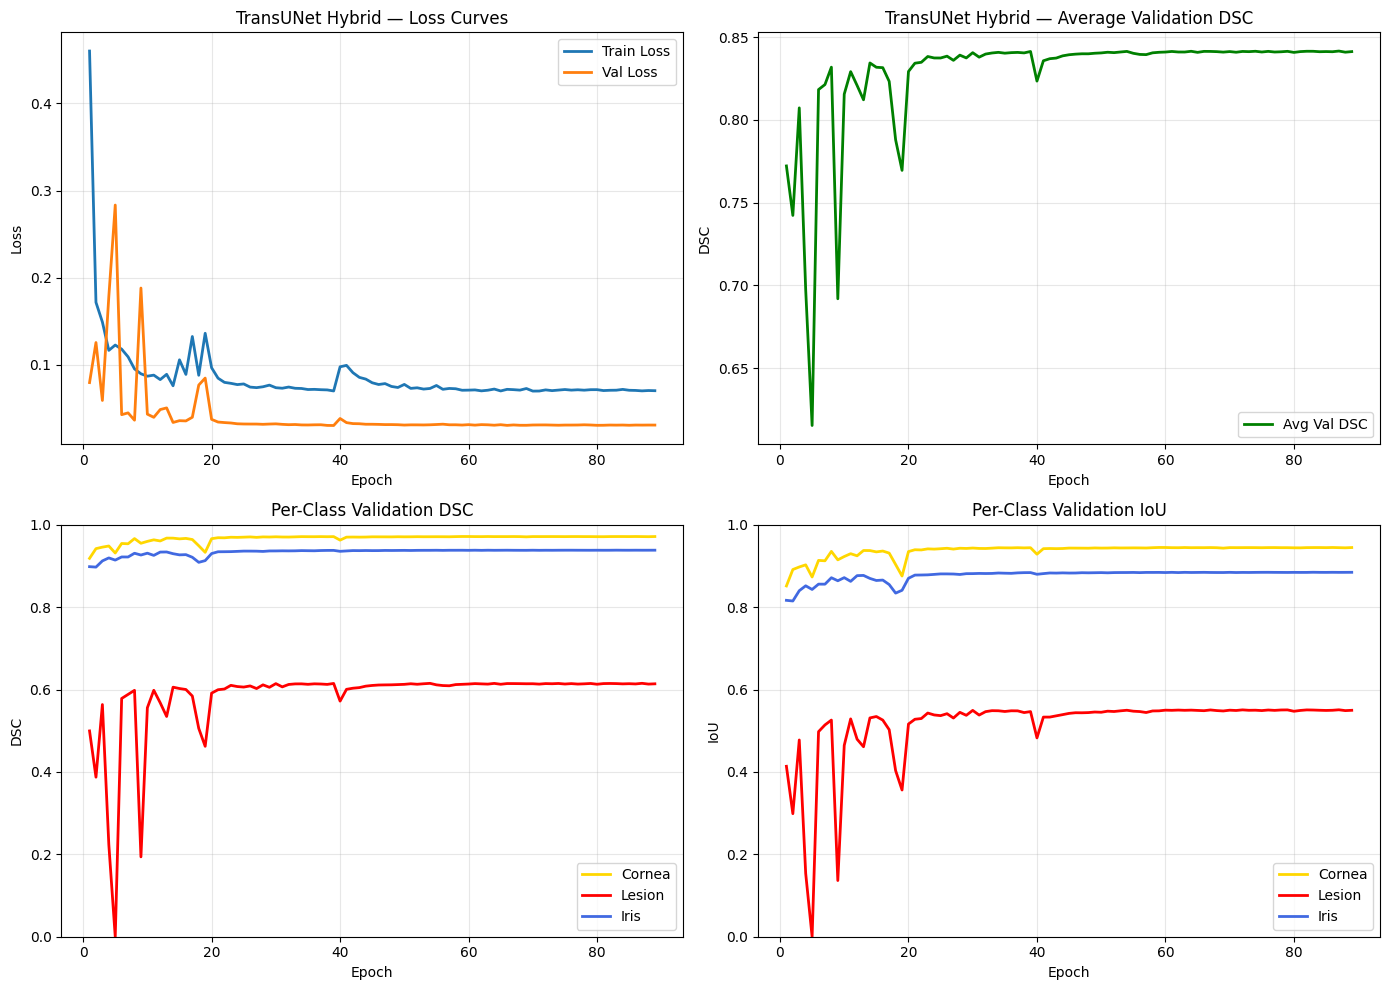

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = list(range(1, len(history['train_loss']) + 1))

ax = axes[0, 0]
ax.plot(epochs, history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(epochs, history['val_loss'], label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('TransUNet Hybrid — Loss Curves')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(epochs, history['val_dsc'], color='green', linewidth=2, label='Avg Val DSC')
ax.set_xlabel('Epoch'); ax.set_ylabel('DSC')
ax.set_title('TransUNet Hybrid — Average Validation DSC')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(epochs, history['cornea_dsc'], label='Cornea', color='gold', linewidth=2)
ax.plot(epochs, history['lesion_dsc'], label='Lesion', color='red', linewidth=2)
if INCLUDE_IRIS:
    ax.plot(epochs, history['iris_dsc'], label='Iris', color='royalblue', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('DSC')
ax.set_title('Per-Class Validation DSC')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.0)

ax = axes[1, 1]
ax.plot(epochs, history['cornea_iou'], label='Cornea', color='gold', linewidth=2)
ax.plot(epochs, history['lesion_iou'], label='Lesion', color='red', linewidth=2)
if INCLUDE_IRIS:
    ax.plot(epochs, history['iris_iou'], label='Iris', color='royalblue', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('IoU')
ax.set_title('Per-Class Validation IoU')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('transunet_hybrid_curves.png', dpi=130, bbox_inches='tight')
plt.show()

## 9 — Visualise Predictions

/tmp/ipykernel_55/1771886394.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


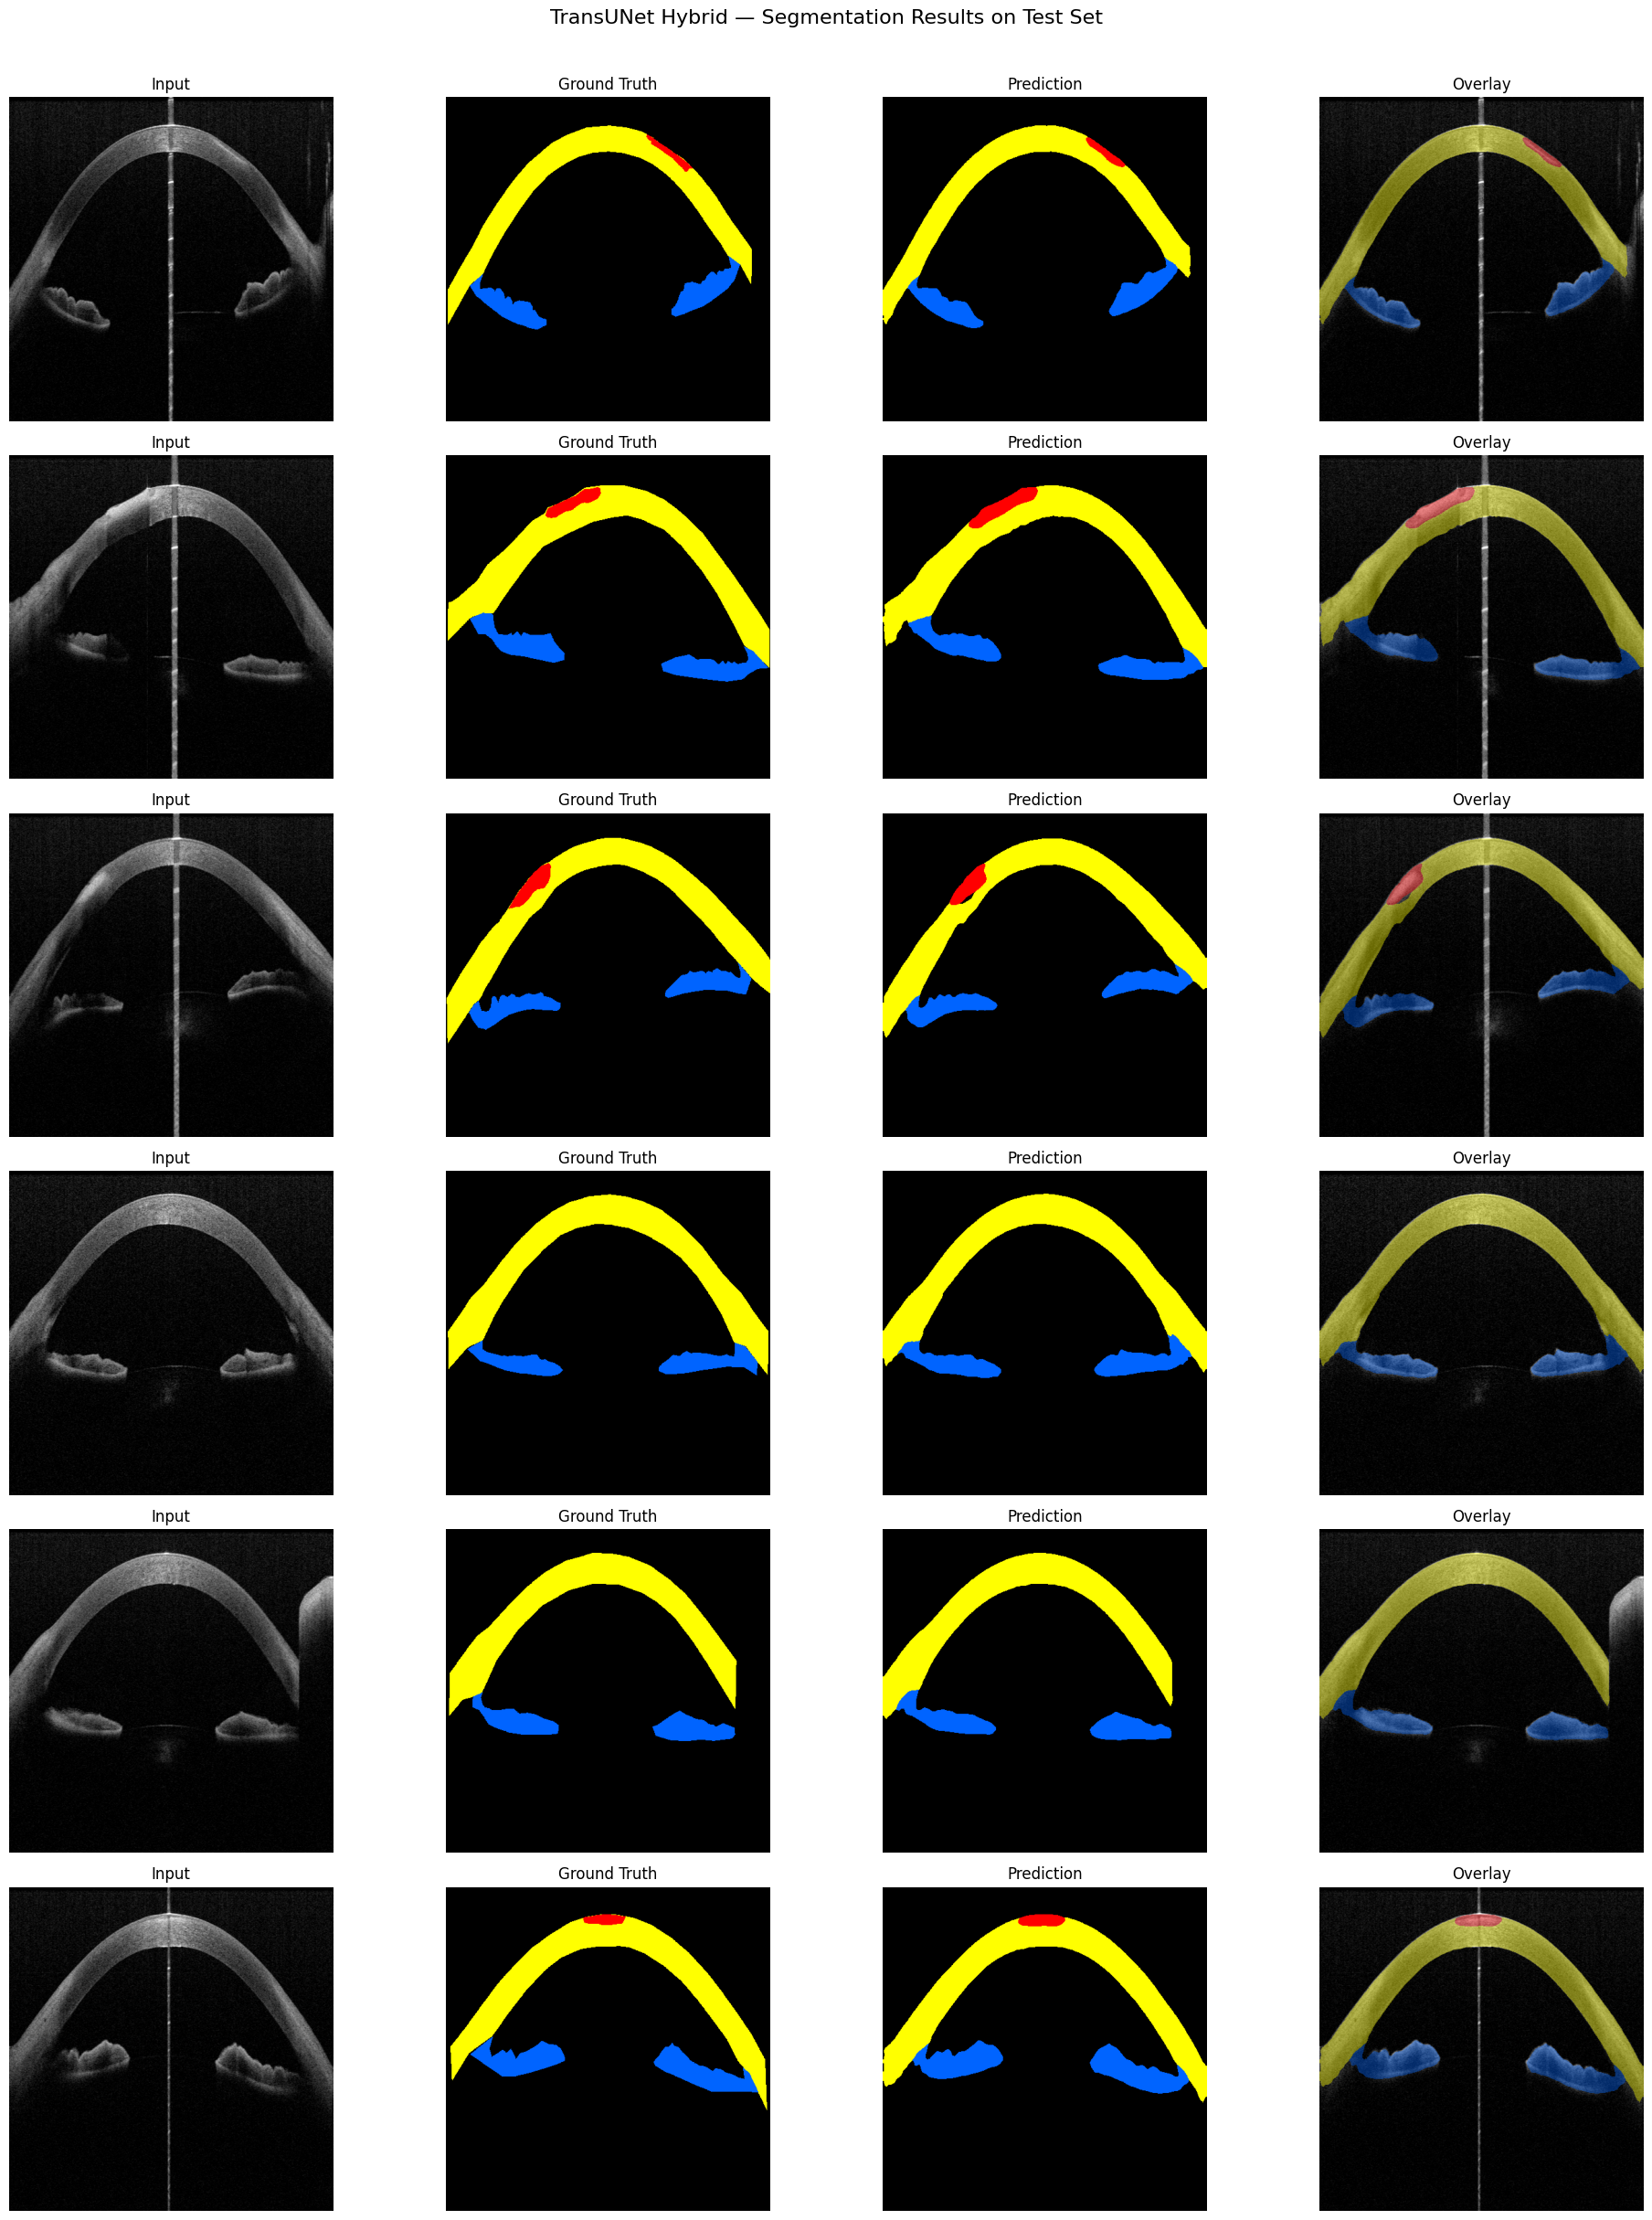

In [23]:
COLORS = np.array([
    [0,   0,   0],
    [255, 255, 0],
    [255, 0,   0],
    [0,   100, 255],
], dtype=np.uint8)


def mask_to_rgb(mask, alpha=0.4, image=None):
    rgb = COLORS[mask]
    if image is not None:
        img_rgb = (image * 255).astype(np.uint8) if image.max() <= 1 else image
        fg = mask > 0
        blended = img_rgb.copy()
        blended[fg] = (alpha * rgb[fg] + (1 - alpha) * img_rgb[fg]).astype(np.uint8)
        return blended
    return rgb


N_VIS = 6
vis_indices = random.sample(range(len(test_ds)), min(N_VIS, len(test_ds)))

fig, axes = plt.subplots(len(vis_indices), 4, figsize=(20, 4 * len(vis_indices)))
if len(vis_indices) == 1:
    axes = axes[np.newaxis, :]

model.eval()
with torch.no_grad():
    for row, idx in enumerate(vis_indices):
        img_t, seg_gt = test_ds[idx]
        with torch.cuda.amp.autocast():
            main_out, _ = model(img_t.unsqueeze(0).to(DEVICE))
            if main_out.shape[2:] != seg_gt.shape[:]:
                main_out = F.interpolate(main_out, size=seg_gt.shape[:],
                                         mode="bilinear", align_corners=False)
        pred = main_out.argmax(dim=1)[0].cpu().numpy()
        gt   = seg_gt.numpy()
        img_np = img_t.permute(1, 2, 0).numpy()

        axes[row, 0].imshow(img_np);              axes[row, 0].set_title("Input")
        axes[row, 1].imshow(mask_to_rgb(gt));      axes[row, 1].set_title("Ground Truth")
        axes[row, 2].imshow(mask_to_rgb(pred));    axes[row, 2].set_title("Prediction")
        axes[row, 3].imshow(mask_to_rgb(pred, image=img_np))
        axes[row, 3].set_title("Overlay")
        for c in range(4):
            axes[row, c].axis("off")

plt.suptitle("TransUNet Hybrid — Segmentation Results on Test Set", fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

---

## 10 — Three-Model Comparison Reference

After running all three models on the same config, fill in this table:

| Metric | ScLNet | UNet Baseline | TransUNet Hybrid |
|--------|--------|---------------|------------------|
| Cornea DSC | 0.9705 | 0.9696 | ___ |
| Cornea HD | 16.35 | 21.01 | ___ |
| Lesion DSC | 0.6713 | 0.6686 | ___ |
| Lesion HD | 7.30 | 7.96 | ___ |
| Iris DSC | 0.9288 | 0.9276 | ___ |
| Iris HD | 13.58 | 13.89 | ___ |
| Params (M) | 92.61 | ~30 | ___ |

### What "success" looks like

- **Strong success:** Lesion DSC > 0.69 (a +0.02 improvement). Confirms the
  transformer global-context hypothesis.
- **Moderate success:** Lesion DSC 0.67–0.69 with notably better HD or fewer skipped
  cases. The model is at least more reliable.
- **Null result:** Lesion DSC 0.65–0.67. Strong evidence that the ceiling is data-limited,
  not architecture-limited. This is a publishable finding in itself — three distinct
  architectures all converging to ~0.67 lesion DSC tells a clear story about the dataset.
- **Failure mode:** Lesion DSC < 0.65. Likely transformer undertraining. Would need to
  retry with pretrained encoder weights or longer training.

Whatever the result, the experiment is informative. A null result strengthens your
'data-limited ceiling' framing for your manager presentation.